<a href="https://colab.research.google.com/github/elaijah18/PRMS2/blob/main/global_economic_indicator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Economic Indicators (2010–2025)

How do we know if a country is rich or poor?
Economic conditions are often measured through a combination of indicators that reflect a nation’s growth, stability, and financial health.

This dataset, sourced from the World Bank, contains year-wise global economic indicators for over 200 countries from 2010 to 2025. The dataset includes key macroeconomic indicators that help explain how economies perform and evolve over time. These indicators measure aspects such as economic growth, price stability, employment levels, government finances, and national income.


# **Preparing the Environment**

In [ ]:
# Import the libraries to be used

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
import numpy as np
%matplotlib inline

In [ ]:
# Import the csv file from drive

from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/Portfolio/world_bank_data_2025.csv"
df = pd.read_csv(file_path)

Mounted at /content/drive


# **Data Exploration**

In [ ]:
# Preview the first 5 rows of the dataset
df.head()

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
0,Aruba,aw,2010,2.078141,2.453597e+09,24093.140151,NaN,11.666131,-1.223407,-2.733457,-18.752537,NaN,NaN,NaN,2.313385e+09,NaN
1,Aruba,aw,2011,4.316297,2.637859e+09,25712.384302,NaN,4.801974,4.005674,3.369237,-9.877656,NaN,NaN,NaN,2.391841e+09,NaN
2,Aruba,aw,2012,0.627472,2.615208e+09,25119.665545,NaN,8.200875,0.184033,-1.040800,3.473451,NaN,NaN,NaN,2.499118e+09,NaN
3,Aruba,aw,2013,-2.372065,2.727850e+09,25813.576727,NaN,10.709709,-1.995948,6.431483,-11.813206,NaN,NaN,NaN,2.563517e+09,NaN
4,Aruba,aw,2014,0.421441,2.790850e+09,26129.839062,NaN,3.213869,3.958897,-1.586575,-4.658577,NaN,NaN,NaN,2.688102e+09,NaN


In [ ]:
# Preview the last 5 rows of the dataset
df.tail()

,country_name,country_id,year,Inflation (CPI %),GDP (Current USD),GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD),Public Debt (% of GDP)
3467,Zimbabwe,zw,2021,98.546105,2.724052e+10,1724.387731,9.540,-31.795551,113.294981,8.468017,1.278300,NaN,NaN,NaN,2.662178e+10,NaN
3468,Zimbabwe,zw,2022,104.705171,3.278975e+10,2040.552459,10.087,-36.833393,266.987152,6.139263,0.930064,NaN,NaN,NaN,3.202694e+10,NaN
3469,Zimbabwe,zw,2023,NaN,3.523137e+10,2156.034004,8.759,-73.540441,921.535652,5.336730,0.379995,NaN,NaN,NaN,3.479607e+10,NaN
3470,Zimbabwe,zw,2024,NaN,NaN,NaN,8.554,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3471,Zimbabwe,zw,2025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Shape of the dataset
df.shape

(3472, 16)

In [ ]:
# Summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3472 entries, 0 to 3471
Data columns (total 16 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country_name                     3472 non-null   object 
 1   country_id                       3472 non-null   object 
 2   year                             3472 non-null   int64  
 3   Inflation (CPI %)                2694 non-null   float64
 4   GDP (Current USD)                2933 non-null   float64
 5   GDP per Capita (Current USD)     2938 non-null   float64
 6   Unemployment Rate (%)            2795 non-null   float64
 7   Interest Rate (Real, %)          1735 non-null   float64
 8   Inflation (GDP Deflator, %)      2904 non-null   float64
 9   GDP Growth (% Annual)            2912 non-null   float64
 10  Current Account Balance (% GDP)  2563 non-null   float64
 11  Government Expense (% of GDP)    1820 non-null   float64
 12  Government Revenue (

# **Data Cleaning**

### **Handling missing values**

In [ ]:
df.isnull().sum()/len(df)*100

,0
country_name,0.000000
country_id,0.000000
year,0.000000
Inflation (CPI %),22.407834
GDP (Current USD),15.524194
GDP per Capita (Current USD),15.380184
Unemployment Rate (%),19.498848
"Interest Rate (Real, %)",50.028802
"Inflation (GDP Deflator, %)",16.359447
GDP Growth (% Annual),16.129032


Majority of the columns have null values, with certain columns exceeding 50% null values

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# Drop columns that are irrelevant to the research objectives

df.drop(['GDP (Current USD)', 'GDP per Capita (Current USD)', 'Interest Rate (Real, %)', 'Inflation (GDP Deflator, %)', 'Current Account Balance (% GDP)', 'Government Revenue (% of GDP)', 'Tax Revenue (% of GDP)', 'Gross National Income (USD)'], axis=1, inplace=True)

df.head(1)

,country_name,country_id,year,Inflation (CPI %),Unemployment Rate (%),GDP Growth (% Annual),Government Expense (% of GDP),Public Debt (% of GDP)
0,Aruba,aw,2010,2.078141,NaN,-2.733457,NaN,NaN


In [ ]:
# Confirming the number of rows before dropping the null values
print(f"Rows before: {len(df)}")

# Drop the null values in the GDP Growth column
df = df.dropna(subset=['GDP Growth (% Annual)'])

# Verify the deleted rows
print(f"Rows after: {len(df)}")

Rows before: 3472
Rows after: 2912


In [ ]:
print(f"Rows before: {len(df)}")

# Creating a new dataframe where we drop the null values for both the Inflation and Unemployment columns
df_inflation_unemployed = df.dropna(subset=['Inflation (CPI %)', 'Unemployment Rate (%)'])

print(f"Rows after: {len(df_inflation_unemployed)}")

Rows before: 2912
Rows after: 2365


In [ ]:
# Analyzing the quantity of null in the data
percent_null = df['Public Debt (% of GDP)'].isna().mean() * 100
print(f"{percent_null:.2f}%")

70.74%


The column Public Debt (% of GDP) contains 70% null values, therefore findings using this variable must be handled cautiously.

In [ ]:
df_public_debt = df.dropna(subset=['Public Debt (% of GDP)'])

In [ ]:
print(f"Rows before: {len(df)}")

# Creating a new dataframe where we drop the null values for both the Government Expense (% of GDP) and GDP Growth (% Annual) columns
df_expense_gdp = df.dropna(subset=['Government Expense (% of GDP)', 'GDP Growth (% Annual)'])

print(f"Rows after: {len(df_expense_gdp)}")

Rows before: 2912
Rows after: 1819


**Exploratory Data Analysis**

1. Which country earns the highest and lowest GDP growth from 2010-2023?

In [ ]:
# During analysis, I found out that most of the countries does not have any record from 2024-2025 for the GDP Growth (% Annual), hence verifying it.
missing_2024 = set(df['country_name'].unique()) - set(
    df[(df['year'] == 2024) & (df['GDP Growth (% Annual)'].notna())]['country_name']
)
len(missing_2024)

missing_2025 = set(df['country_name'].unique()) - set(
    df[(df['year'] == 2025) & (df['GDP Growth (% Annual)'].notna())]['country_name']
)
len(missing_2025)

213

With this, the calculation for GDP Growth (% Annual) will come from 2010-2023 only.

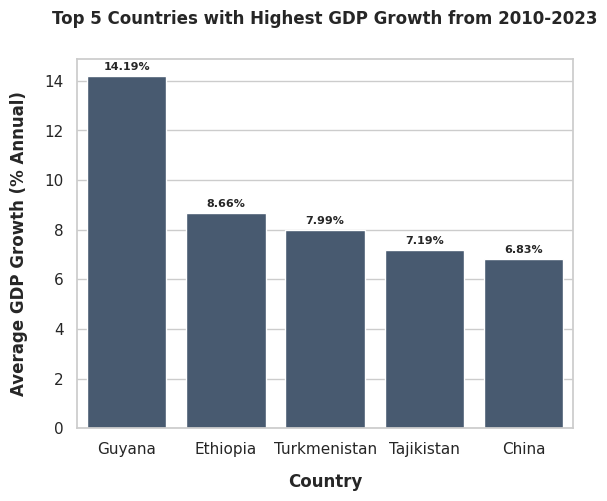

In [ ]:
# Filter the years to get the GDP growth of countries with consistent record from 2010-2023
df_filtered_years = df[(df['year'] >= 2010) & (df['year'] <= 2023)]
df_filtered_years = df_filtered_years.dropna(subset=['GDP Growth (% Annual)'])

# Getting the mean
mean_gdp_growth = (
    df_filtered_years
    .groupby('country_name')['GDP Growth (% Annual)']
    .mean()
    .reset_index(name='mean_gdp_growth')
)

# Plot Bar Chart
sns.set_theme(style="whitegrid")

top5 = (
    mean_gdp_growth
    .sort_values('mean_gdp_growth', ascending=False)
    .head(5)
)

ax = sns.barplot(data=top5, x='country_name', y='mean_gdp_growth', color='#415a77')
ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3, fontsize=8, fontweight='bold')
plt.xlabel("Country", fontweight="bold", labelpad=12)
plt.ylabel("Average GDP Growth (% Annual)", fontweight="bold", labelpad=12)
plt.title("Top 5 Countries with Highest GDP Growth from 2010-2023", fontweight="bold", fontsize=12, pad=25)


plt.show()


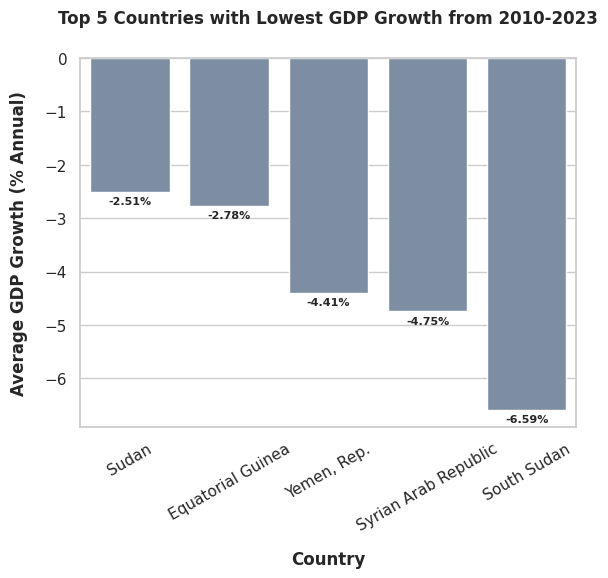

In [ ]:
least5 = (
    mean_gdp_growth
    .sort_values('mean_gdp_growth', ascending=False)
    .tail(5)
)

ax = sns.barplot(data=least5, x='country_name', y='mean_gdp_growth', color='#778da9')
ax.bar_label(ax.containers[0], fmt='%.2f%%', padding=3, fontsize=8, fontweight='bold')
plt.xlabel("Country", fontweight="bold", labelpad=12)
plt.xticks(rotation=30)
plt.ylabel("Average GDP Growth (% Annual)", fontweight="bold", labelpad=12)
plt.title("Top 5 Countries with Lowest GDP Growth from 2010-2023", fontweight="bold", fontsize=12, pad=25)


plt.show()


Let's analyze the chart:


*   Guyana has the highest GDP growth from 2010-2023, earning a huge gap from other countries.
*   On contrary, South Sudan earned the lowest average GDP growth of -6%, leaving a significant gap from countries with the highest value.
* Notably, it is recognizable that the countries with the lowest GDP growth are from Africa, whereas the highest growth rates are concentrated in Asia.




2. Which country shows consistent economic expansion?

In [ ]:
# The criteria used in identifying the countries with consistent economic expansion are:
# (a) the average GDP Growth (% Annual), (b) standard deviation of growth, (c) number of positive-growth years

summary = (
    df.groupby("country_name")["GDP Growth (% Annual)"]
    .agg(
        avg_growth="mean",
        std_growth="std",
        positive_growth_years=lambda x: (x > 0).sum()
    )
    .reset_index()
)

# Normalize positive metrics (higher = better)
summary["avg_norm"] = (summary["avg_growth"] - summary["avg_growth"].min()) / (
    summary["avg_growth"].max() - summary["avg_growth"].min()
)

summary["pos_norm"] = (summary["positive_growth_years"] - summary["positive_growth_years"].min()) / (
    summary["positive_growth_years"].max() - summary["positive_growth_years"].min()
)

# Normalize volatility (lower std = better, so reverse it)
summary["std_norm"] = 1 - (
    (summary["std_growth"] - summary["std_growth"].min()) /
    (summary["std_growth"].max() - summary["std_growth"].min())
)

# Get the consistency score by getting the average of the metrics

summary["consistency_score"] = (
    summary["avg_norm"] +
    summary["pos_norm"] +
    summary["std_norm"]
) / 3

consistent_countries = (
    summary
    .sort_values("consistency_score", ascending=False)
    .head(10)
)

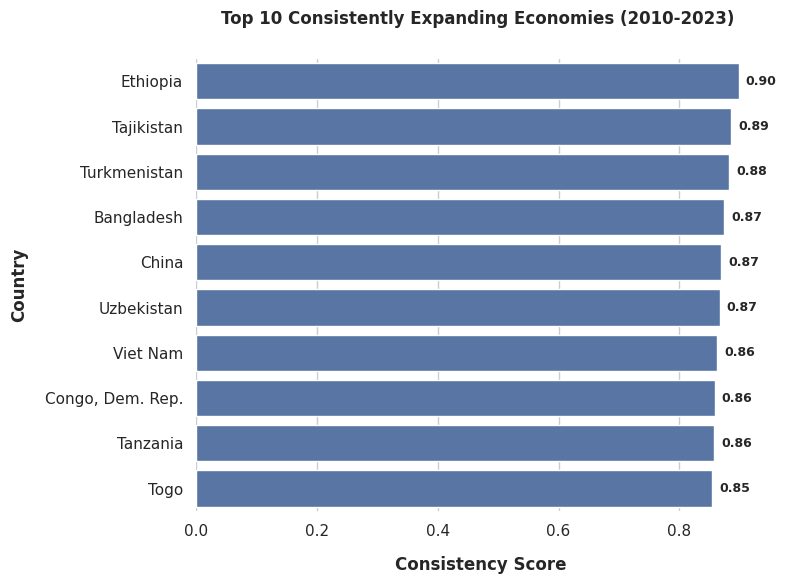

In [ ]:
# Plot the bar chart

plt.figure(figsize=(8,6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(data=consistent_countries, y='country_name', x='consistency_score')
ax.bar_label(ax.containers[0], fmt='%.2f', padding=5, fontsize=9, fontweight='bold')
plt.ylabel("Country", fontweight="bold", labelpad=12)
plt.xlabel("Consistency Score", fontweight="bold", labelpad=12)
plt.title("Top 10 Consistently Expanding Economies (2010-2023) ", fontweight="bold", fontsize=12, pad=25)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()


Here, we can deduce that majority of the Top 5 countries with highest GDP growth also has the most consistent expanding economic for 14 years with Ethiopia earning the highest score.

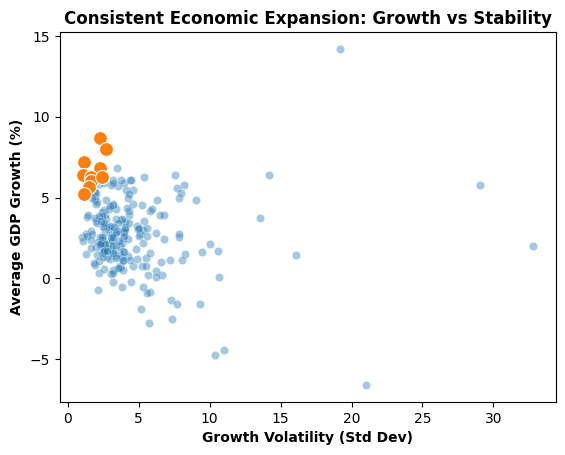

In [ ]:
# Plot the scatter plot to show all the criteria

sns.scatterplot(x="std_growth", y="avg_growth", data=summary, alpha=0.4)

sns.scatterplot(
    x="std_growth",
    y="avg_growth",
    data=consistent_countries,
    s=100
)

plt.xlabel("Growth Volatility (Std Dev)", fontweight="bold")
plt.ylabel("Average GDP Growth (%)", fontweight="bold")
plt.title("Consistent Economic Expansion: Growth vs Stability", fontweight="bold")

plt.show()

3. Do countries with high inflation also experience high unemployment?

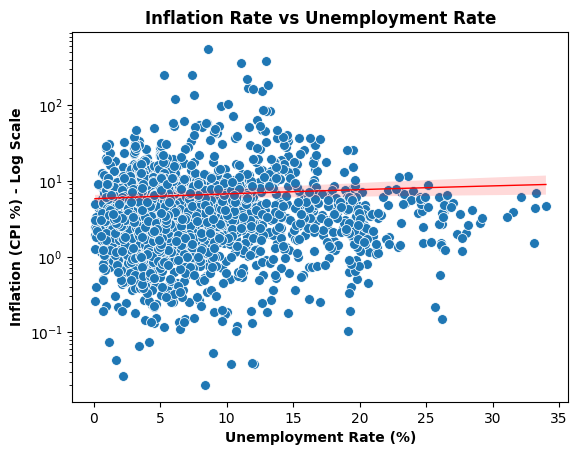

In [ ]:
# Plot the scatter plot

fig, ax = plt.subplots()

sns.scatterplot(x="Unemployment Rate (%)", y="Inflation (CPI %)", data=df_inflation_unemployed, s=50, ax=ax)

# Add trend line
sns.regplot(x="Unemployment Rate (%)", y="Inflation (CPI %)", data=df_inflation_unemployed,
            scatter=False, ax=ax, color="red", line_kws={"linewidth": 1})

# Since there are extreme outliers, I used log to compress the values
ax.set_yscale("log")

ax.set_xlabel("Unemployment Rate (%)", fontweight="bold")
ax.set_ylabel("Inflation (CPI %) - Log Scale", fontweight="bold")
ax.set_title("Inflation Rate vs Unemployment Rate", fontweight="bold")

plt.show()

The trend line shows a very slight positive slope, suggesting a weak positive relationship between the variables. As unemployment rate increases, inflation tends to increase also slightly.

# **Conclusion**

Let us revisit the questions and summarize our conclusion.

**Q1: Which country earns the highest and lowest GDP growth from 2010-2023?**

> Between 2010 and 2023, the global economic landscape was defined by a huge contrast in performance, with Guyana emerging as the clear leader. Its explosive GDP growth created a massive statistical lead over all other nations. On the opposite end of the spectrum, South Sudan struggled significantly, earning a dismal average growth rate of -6%, which placed it at the bottom of the global rankings by a wide margin. Geographically, these trends reveal a distinct regional divide: while the highest concentrations of rapid economic expansion were found across Asia, the countries facing the most severe economic contractions or stagnant growth were predominantly located in Africa.

**Q2: Which country shows consistent economic expansion?**
>  Ethiopia, Tajikistan, Turkmenistan, Bangladesh, China, Uzbekistan, Viet Nam, Congo, Dem. Rep., Tanzania, Togo are the top 10 countries


**Q3: Do countries with high inflation also experience high unemployment?**
>  There is a weak positive relationship, indicating that as unemployment rate increases, there is a slight change for inflation to increase as well.

Overall, while some countries in Asia and Africa show very fast economic growth, the data also shows that inflation and unemployment usually go up together in a minor but noticeable way.